In [2]:
import os
import pandas as pd
import json
import numpy as np


#### Baseline

In [3]:
def get_baseline_result_df(dataset,test_file_name='test_result.json'): 
    if dataset == 'brexit':
        result_path = "../results/roberta-base/brexit/Hate/"
        n_anns = 6

    elif dataset == 'mfrc':
        result_path = "../results/roberta-base/mfrc/Moral/"
        n_anns = "24"

        
    
    records = []
    for root, subdirs, files in os.walk(result_path):
        if f'mtl_{n_anns}' in root :
            for file in files:
                    if file == f'{test_file_name}':
                        with open(os.path.join(root, file), 'r') as f:
                            data = json.load(f)
                            seed=root.split('/')[-4]
                            budget = root.split('/')[-3].split('_')[-1]
                            for i,ann in enumerate(data['task_name']):
                                records.append({'seed':seed, 'budget':budget, 'Annotator':ann, 
                                                'f1': data['f1'][i]})
    df = pd.DataFrame(records)
    return df

def get_baseline_performance_variance_across_anns(df):
    df= df.groupby(['seed', 'budget']).agg({'f1': ['mean', 'std']}).reset_index()
    df.columns = df.columns.map('_'.join).str.strip('_')
    df = df.groupby(['budget']).agg({'f1_mean': ['mean', 'std' ]}).reset_index()
    df.columns = df.columns.map('_'.join).str.strip('_')
    df = df.rename(columns={'f1_mean_mean': 'f1_mean', 'f1_mean_std': 'f1_std'})
    return df

### Our method (MTLs)

In [4]:
def get_mtl_result_df(dataset,test_file_name='test_result.json'): 
    if dataset == 'brexit':
        result_path = "../results/roberta-base/brexit/Hate/"
        n_anns = 6

    elif dataset == 'mfrc':
        result_path = "../results/roberta-base/mfrc/Moral/"
        n_anns = 24
        
    records = []
    for root, subdirs, files in os.walk(result_path):
        if (f'mtl' in root) and (f'mtl_{n_anns}' not in root) and ("few_shot") not in root :
            for file in files:
                    if file == f'{test_file_name}':
                        with open(os.path.join(root, file), 'r') as f:
                            data = json.load(f)
                            mtl_tasks = str.join(',',data['task_name'])
                            seed=root.split('/')[-4]
                            budget = root.split('/')[-3].split('_')[-1]
                            for i,ann in enumerate(data['task_name']):
                                records.append({'seed':seed, 'budget':budget, 'Annotator':ann,
                                                'mtl_tasks':mtl_tasks,
                                                'f1': data['f1'][i]})
                                
    df = pd.DataFrame(records)
    return df

### Our method (FS)

In [5]:
def get_fs_result_df(dataset,test_file_name='test_result.json'): 
    if dataset == 'brexit':
        result_path = "../results/roberta-base/brexit/Hate/"
        n_anns = 6

    elif dataset == 'mfrc':
        result_path = "../results/roberta-base/mfrc/Moral/"
        n_anns = 24
        
    records = []
    for root, subdirs, files in os.walk(result_path):
        if "few_shot" in root :
            for file in files:
                    if file == f'{test_file_name}':
                        with open(os.path.join(root, file), 'r') as f:
                            data = json.load(f)
                            annotator = root.split('/')[-2]
                            k_shot = root.split('/')[-3]
                            sampling = root.split('/')[-5]
                            mtl = root.split('/')[-1].split('_')[-2]
                            budget = root.split("/")[-7].split('_')[-1]
                            seed = root.split('/')[-8]
                            
                            records.append({'seed': seed, 'sampling' : sampling, 'budget': budget,
                                            'k_shot': k_shot ,
                                            'Annotator':annotator,  'mtl_tasks': mtl,
                                            'f1': data['f1']})
    df = pd.DataFrame(records)
    return df

In [6]:

def get_mtl_fs_df(df, df_mtl):

    sampling_methods = df['sampling'].unique()
    shots = df['k_shot'].unique()

    dfs_sample_shot = []
    columns = ['seed', 'budget', 'mtl_tasks' ,'Annotator', 'f1']
    for sampling in sampling_methods:
        for shot in shots:
            df_samp_shot = df[(df['sampling'] == sampling) & (df['k_shot'] == shot)]
            df_samp_shot = df_samp_shot[columns]
            df_samp_shot = pd.concat([df_samp_shot, df_mtl])
            
            # first get the average of a performance for one anntoator acroos models
            df_samp_shot = df_samp_shot.groupby(['seed', 'budget', 'Annotator']).agg({'f1': 'mean'}).reset_index()
            
            #get the average the model in one seed
            # df_samp_shot = df_samp_shot.groupby(['seed', 'budget']).agg({'f1': ['mean','std']}).reset_index()
            # df_samp_shot.columns = df_samp_shot.columns.map('_'.join).str.strip('_')
            # print(df_samp_shot.columns)
            # get the mean and std across seeds
            df_samp_shot = df_samp_shot.groupby(['budget', 'Annotator']).agg({'f1': ['mean', 'std']}).reset_index()
            df_samp_shot.columns = df_samp_shot.columns.map('_'.join).str.strip('_')
            df_samp_shot = df_samp_shot.rename(columns={'f1_mean': 'F1'})
            
            df_samp_shot['sampling'] = sampling
            df_samp_shot['k_shot'] = shot
            dfs_sample_shot.append(df_samp_shot)
            
    df_sample_shot = pd.concat(dfs_sample_shot)
    return df_sample_shot



### Brexit

In [45]:
dataset = 'brexit'

df_mtl= get_mtl_result_df(dataset)
df = get_fs_result_df(dataset)

df = get_mtl_fs_df(df, df_mtl)
df.head

<bound method NDFrame.head of    budget Annotator        F1    f1_std           sampling k_shot
0     0.5      Ann1  0.321360  0.006787  strategy_balanced     16
1     0.5      Ann2  0.329527  0.018327  strategy_balanced     16
2     0.5      Ann3  0.373849  0.018577  strategy_balanced     16
3     0.5      Ann4  0.548718  0.020110  strategy_balanced     16
4     0.5      Ann5  0.599047  0.026660  strategy_balanced     16
..    ...       ...       ...       ...                ...    ...
13   0.83      Ann2  0.322231  0.014485        strategy_mv     32
14   0.83      Ann3  0.376072  0.028682        strategy_mv     32
15   0.83      Ann4  0.571386  0.013086        strategy_mv     32
16   0.83      Ann5  0.606174  0.019759        strategy_mv     32
17   0.83      Ann6  0.540569  0.013350        strategy_mv     32

[288 rows x 6 columns]>

In [46]:
dataset = 'brexit'
df_b = get_baseline_result_df(dataset)
df_b  = df_b.groupby(['budget', 'Annotator']).agg({'f1': ['mean', 'std']}).reset_index()
df_b.columns = df_b.columns.map('_'.join).str.strip('_')
df_b = df_b.rename(columns={'f1_mean': 'F1'})
df_b['sampling'] = 'baseline'
df_b['k_shot'] = 'baseline'
df_b.head()
df = pd.concat([df, df_b])
df.head()
df_b.groupby(['budget', 'Annotator']).count()

F1  f1_std  sampling  k_shot
budget Annotator                              
0.5    Ann1        1       1         1       1
       Ann2        1       1         1       1
       Ann3        1       1         1       1
       Ann4        1       1         1       1
       Ann5        1       1         1       1
       Ann6        1       1         1       1
0.66   Ann1        1       1         1       1
       Ann2        1       1         1       1
       Ann3        1       1         1       1
       Ann4        1       1         1       1
       Ann5        1       1         1       1
       Ann6        1       1         1       1
0.83   Ann1        1       1         1       1
       Ann2        1       1         1       1
       Ann3        1       1         1       1
       Ann4        1       1         1       1
       Ann5        1       1         1       1
       Ann6        1       1         1       1
1.0    Ann1        1       1         1       1
       Ann2        1       1         1       1
       Ann3        1       1         1       1
       Ann4        1       1         1       1
       Ann5        1       1         1       1
       Ann6        1       1         1       1

/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Catego

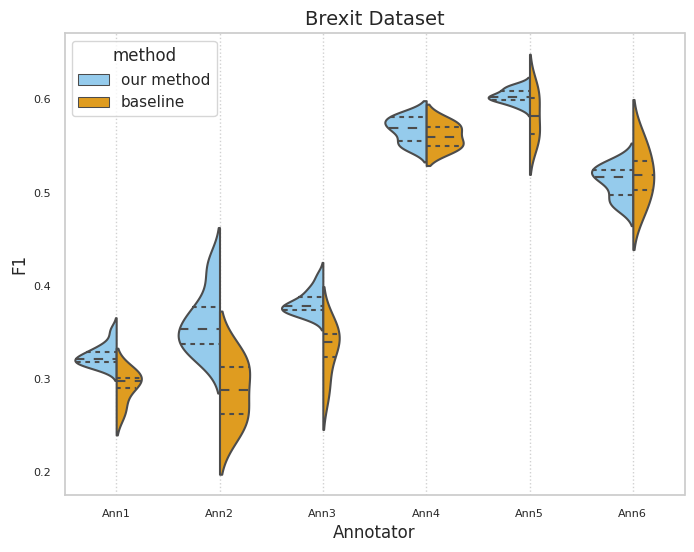

/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Catego

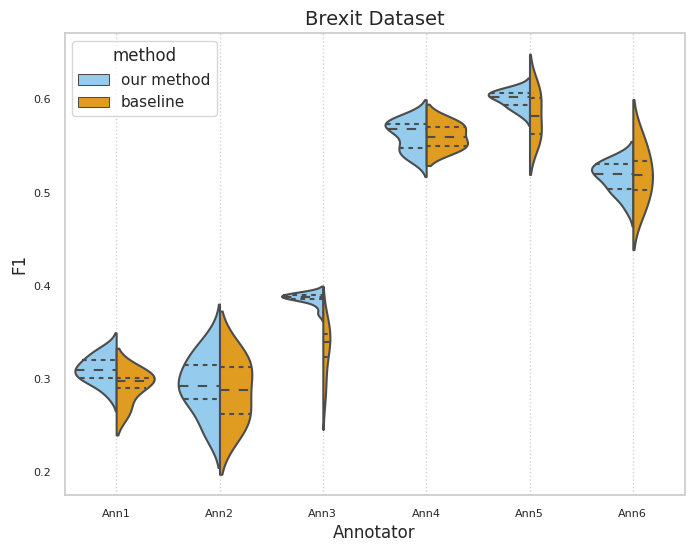

/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Catego

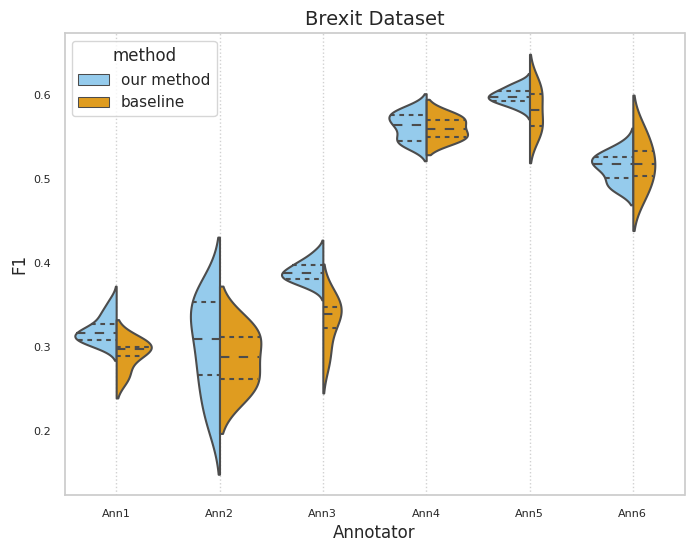

/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Catego

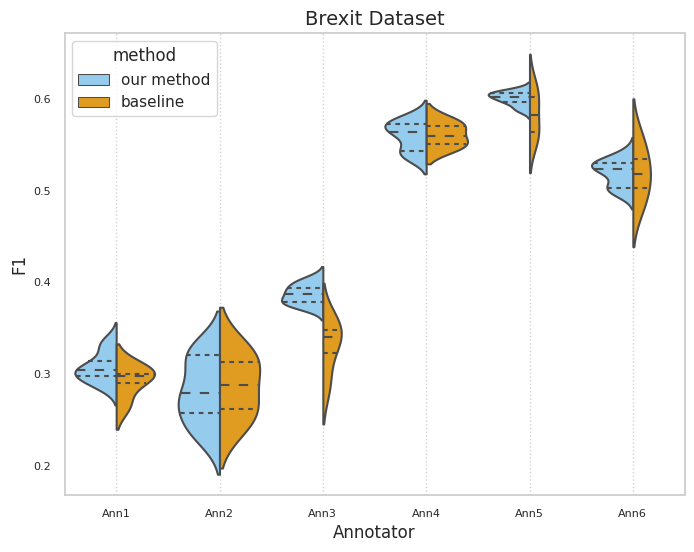

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

s= df['sampling'].unique().tolist()
s =  [i for i in s if i != 'baseline']

for sampling in s:
        df_sampling = df[df['sampling'].isin([sampling, 'baseline'])]
        df_sampling = df_sampling.rename(columns={'sampling': 'method'})
        df_sampling['method'] = df_sampling['method'].replace({'baseline': 'baseline',
                                                               f"{sampling}": 'our method'})
        sorted_annotators = df_sampling.groupby("Annotator")["F1"].mean().sort_values().index.to_list()
        sorted_annotators
        sns.set(rc={'figure.figsize': (8, 6)})

        sns.set_style("whitegrid")


        # colors = {"0.5": "skyblue","0.66": "dodgerblue",
        #             "0.83": "darkblue", "1.0": "orangered"}
        colors = { "our method": "lightskyblue", "baseline": "orange"}


        # ax = sns.swarmplot(data=df_sampling, x="Annotator", y="F1", hue="sampling",
        #                 palette=colors, order=sorted_annotators)
        
        ax = sns.violinplot(data=df_sampling, x="Annotator", y="F1", hue="method",  split=True, inner="quart",
                             palette=colors)

        sns.despine(ax=ax, left=False, right=False, bottom=False, top=False, trim=False)
        
        # plt.legend(labels=["Our method", "Versicolor", "Virginica"])

        # plt.legend(title='Smoker', loc='upper left', labels=['Hell Yeh', 'Nah Bruh'])
        ax.xaxis.grid(True, linestyle=':', alpha=0.9)
        ax.yaxis.grid(False)

        # plt.xticks(df_sampling["Annotator"])
        ax.tick_params(labelsize=8)

        plt.title(f"Brexit Dataset", fontsize=14)
        plt.show()

### MFRC

In [29]:
dataset = 'mfrc'

columns = ['seed', 'budget', 'Annotator', 'f1']

df_mtl= get_mtl_result_df(dataset)
df = get_fs_result_df(dataset)

df = get_mtl_fs_df(df, df_mtl)

df_b = get_baseline_result_df(dataset)
df_b  = df_b.groupby(['budget', 'Annotator']).agg({'f1': ['mean', 'std']}).reset_index()
df_b.columns = df_b.columns.map('_'.join).str.strip('_')
df_b = df_b.rename(columns={'f1_mean': 'F1'})
df_b['sampling'] = 'baseline'
df_b['k_shot'] = 'baseline'
df_b.head()
df = pd.concat([df, df_b])
df.head()


,budget,Annotator,F1,f1_std,sampling,k_shot
0,0.25,0,0.909513,0.013496,strategy_balanced,16
1,0.25,1,0.824573,0.018932,strategy_balanced,16
2,0.25,10,0.724618,0.021047,strategy_balanced,16
3,0.25,11,0.733714,0.008137,strategy_balanced,16
4,0.25,12,0.761995,0.004850,strategy_balanced,16


/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/golazizi/2DIS/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


ConversionError: Failed to convert value(s) to axis units: 0      0
1      1
2     10
3     11
4     12
      ..
91     5
92     6
93     7
94     8
95     9
Name: Annotator, Length: 384, dtype: object

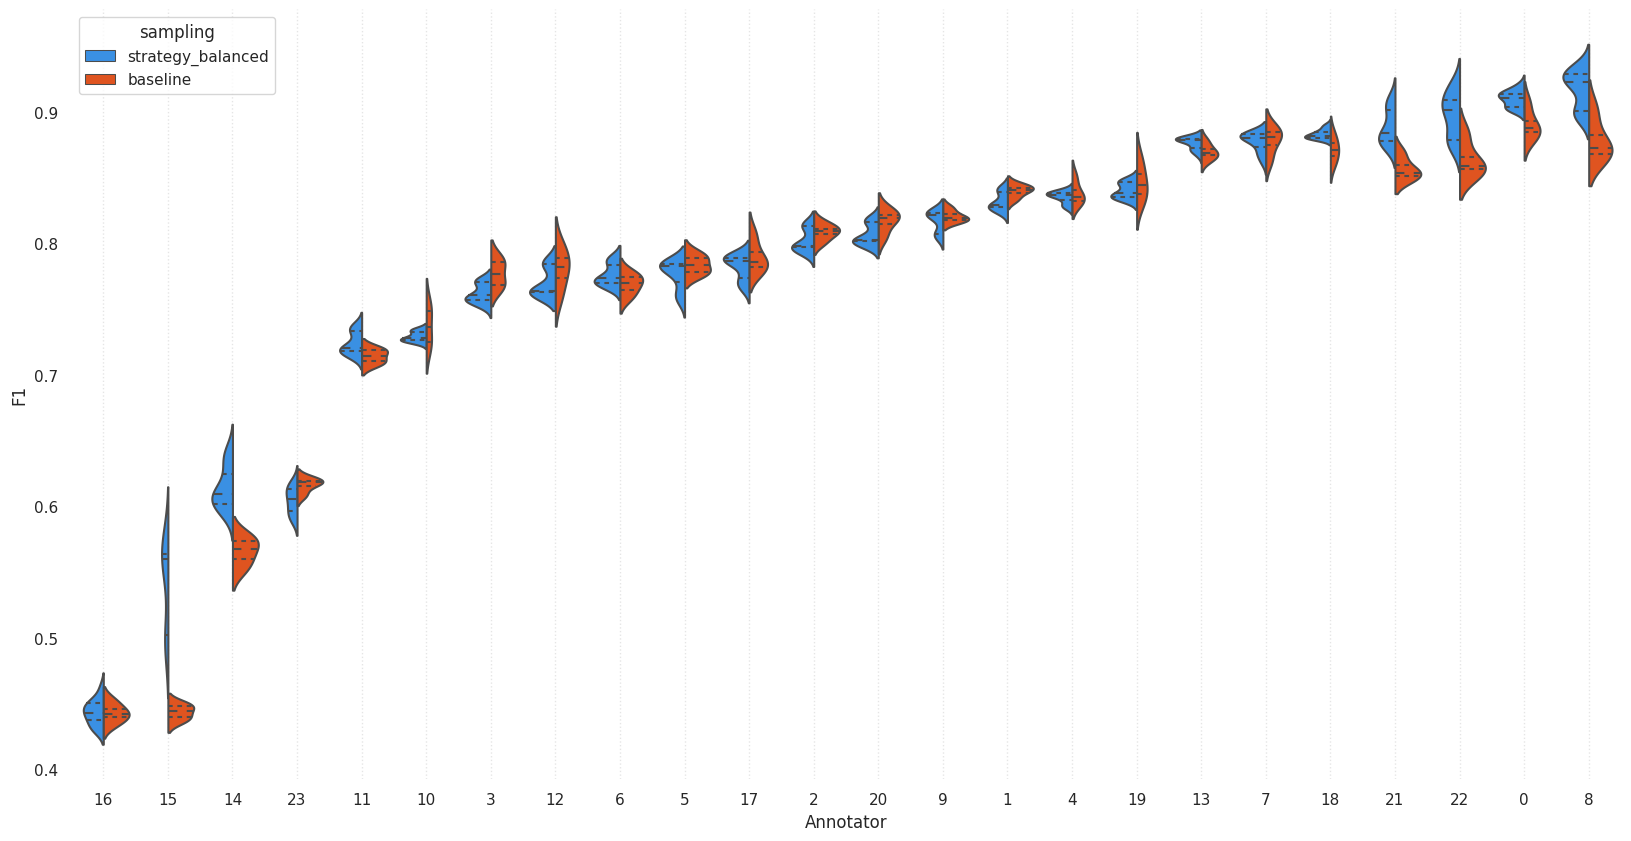

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

s= df['sampling'].unique().tolist()
s =  [i for i in s if i != 'baseline']

for sampling in s:
        df_sampling = df[df['sampling'].isin([sampling, 'baseline'])]
        # df_sampling = df_sampling[df_sampling['budget'].isin(['0.25', '0.5'])]

        sorted_annotators = df_sampling.groupby("Annotator")["F1"].mean().sort_values().index.to_list()
        sorted_annotators
        sns.set(rc={'figure.figsize': (20, 10)})

        sns.set_style("whitegrid")


        # colors = {"0.5": "skyblue","0.66": "dodgerblue",
        #             "0.83": "darkblue", "1.0": "orangered"}
        colors = {f"{sampling}": "dodgerblue", "baseline": "orangered"}


        # ax = sns.swarmplot(data=df_sampling, x="Annotator", y="F1", hue="sampling",
        #                 palette=colors, order=sorted_annotators)
        # ax = sns.violinplot(data=df_sampling, x="Annotator", y="F1", hue="sampling", order=sorted_annotators,
        #                      palette=colors)
        ax = sns.violinplot(data=df_sampling, x="Annotator", y="F1", hue="sampling", order=sorted_annotators,
                            split=True, inner="quart",
                             palette=colors)

        sns.despine(ax=ax, left=True, right=True, bottom=True, top=True, trim=False)

        ax.xaxis.grid(True, linestyle=':', alpha=0.5)
        ax.yaxis.grid(False)

        plt.xticks(df_sampling["Annotator"])
        ax.tick_params(labelsize=8)

        plt.title(f"Brexit {sampling} sampling", fontsize=14)
        plt.show()

In [31]:
df_mfrc
print(pd.merge(df_brexit, df_mfrc, left_index=True, right_index=True).to_latex())

NameError: name 'df_mfrc' is not defined

### Baselines

In [52]:
dataset = 'mfrc'
df = get_baseline_result_df(dataset)
df_mean_var = get_baseline_performance_variance_across_anns(df)
df_mean_var = df_mean_var.round(3)
df_mean_var['f1']  = df_mean_var['f1_mean'].astype(str) + "(" +df_mean_var['f1_std'].astype(str) + ")"
df_mean_var.transpose().drop(['f1_mean', 'f1_std'])

In [ ]:
dataset = 'brexit'
df = get_baseline_result_df(dataset)
df_mean_var = get_baseline_performance_variance_across_anns(df)
df_mean_var = df_mean_var.round(3)
df_mean_var['f1']  = df_mean_var['f1_mean'].astype(str) + "(" +df_mean_var['f1_std'].astype(str) + ")"
df_mean_var.transpose().drop(['f1_mean', 'f1_std'])